Лабораторная работа №2 по ММО АСОИУ
Перевощиков Н.Д.
ИУ5Ц-21М

# Обработка признаков (часть 2)

Цель лабораторной работы: изучение продвинутых способов предварительной обработки данных для дальнейшего формирования моделей.

Задание:
1. Выбрать один или несколько наборов данных (датасетов) для решения следующих задач. Каждая задача может быть решена на отдельном датасете, или несколько задач могут быть решены на одном датасете. Просьба не использовать датасет, на котором данная задача решалась в лекции.
2. Для выбранного датасета (датасетов) на основе материалов лекций решить следующие задачи:
- масштабирование признаков (не менее чем тремя способами);
- обработку выбросов для числовых признаков (по одному способу для удаления выбросов и для замены выбросов);
- обработку по крайней мере одного нестандартного признака (который не является числовым или категориальным);
- отбор признаков:
один метод из группы методов фильтрации (filter methods);
один метод из группы методов обертывания (wrapper methods);
один метод из группы методов вложений (embedded methods).

## Набор данных о результативности и рыночной стоимости игроков FIFA:

Этот набор данных предназначен для анализа эффективности профессиональных футболистов, их навыков и динамики рыночной стоимости на основе аналитики игроков в стиле FIFA. Каждая запись представляет отдельного футболиста и содержит информацию о его игре на поле, физических данных и экономической оценке.

Набор данных моделирует реалистичные взаимосвязи между возрастом игрока, его позицией, общим рейтингом, потенциалом роста, статистикой выступлений в матчах и предполагаемой рыночной стоимостью, что делает его подходящим для продвинутой спортивной аналитики и машинного обучения.

### Сведения о наборе данных:

- Общее количество записей: 2800
- Степень детализации: данные по сезонам для каждого игрока

### Включенные ключевые функции:

- Демографические данные игрока (возраст, гражданство, позиция)
- Общий рейтинг и потенциальный счет
- Показатели результативности в матчах (голы, передачи, сыгранные минуты)
- Физические и технические характеристики
- Показатели клуба и лиги
- Ориентировочная рыночная стоимость (целевая переменная)
- Срок контракта и показатели опыта

### Столбцы:
- player_id - идентификатор игрока
- player_name - имя игрока
- age - возраст
- nationality - национальность
- club - клуб
- position - позиция
- overall_rating - общий рейтинг
- potential_rating - потенциальный рейтинг
- matches_played - сыгранные матчи
- goals - голы
- assists - голевые передачи
- minutes_played - сыгранные минуты
- market_value_million_eur - рыночная стоимость (в миллионах евро)
- contract_years_left - количество лет до окончания контракта
- injury_prone - склонность к травмам
- transfer_risk_level - уровень риска при трансфере

### Подключение библиотеки

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

### Загрузка и информация данных

In [7]:
# Загрузка данных
df = pd.read_csv('fifa_player_performance_market_value.csv')

In [8]:
# Общая информация о датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 2800 non-null   int64  
 1   player_name               2800 non-null   object 
 2   age                       2800 non-null   int64  
 3   nationality               2800 non-null   object 
 4   club                      2800 non-null   object 
 5   position                  2800 non-null   object 
 6   overall_rating            2800 non-null   int64  
 7   potential_rating          2800 non-null   int64  
 8   matches_played            2800 non-null   int64  
 9   goals                     2800 non-null   int64  
 10  assists                   2800 non-null   int64  
 11  minutes_played            2800 non-null   int64  
 12  market_value_million_eur  2800 non-null   float64
 13  contract_years_left       2800 non-null   int64  
 14  injury_p

In [9]:
# Первые 5 строк датасета
df.head()

,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,Yes,Medium
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,No,Low


In [10]:
# Разделим признаки на числовые и категориальные
numeric_features = ['age', 'overall_rating', 'potential_rating', 'matches_played',
                    'goals', 'assists', 'minutes_played', 'market_value_million_eur',
                    'contract_years_left']

categorical_features = ['nationality', 'club', 'position', 'injury_prone', 'transfer_risk_level']

### 1. Устранение пропусков в данных

In [12]:
# Проверка на наличие пропусков
print("Проверка на наличие пропусков:")
df.isnull().sum()

Проверка на наличие пропусков:


player_id                   0
player_name                 0
age                         0
nationality                 0
club                        0
position                    0
overall_rating              0
potential_rating            0
matches_played              0
goals                       0
assists                     0
minutes_played              0
market_value_million_eur    0
contract_years_left         0
injury_prone                0
transfer_risk_level         0
dtype: int64

Числовые признаки (9): ['age', 'overall_rating', 'potential_rating', 'matches_played', 'goals', 'assists', 'minutes_played', 'market_value_million_eur', 'contract_years_left']


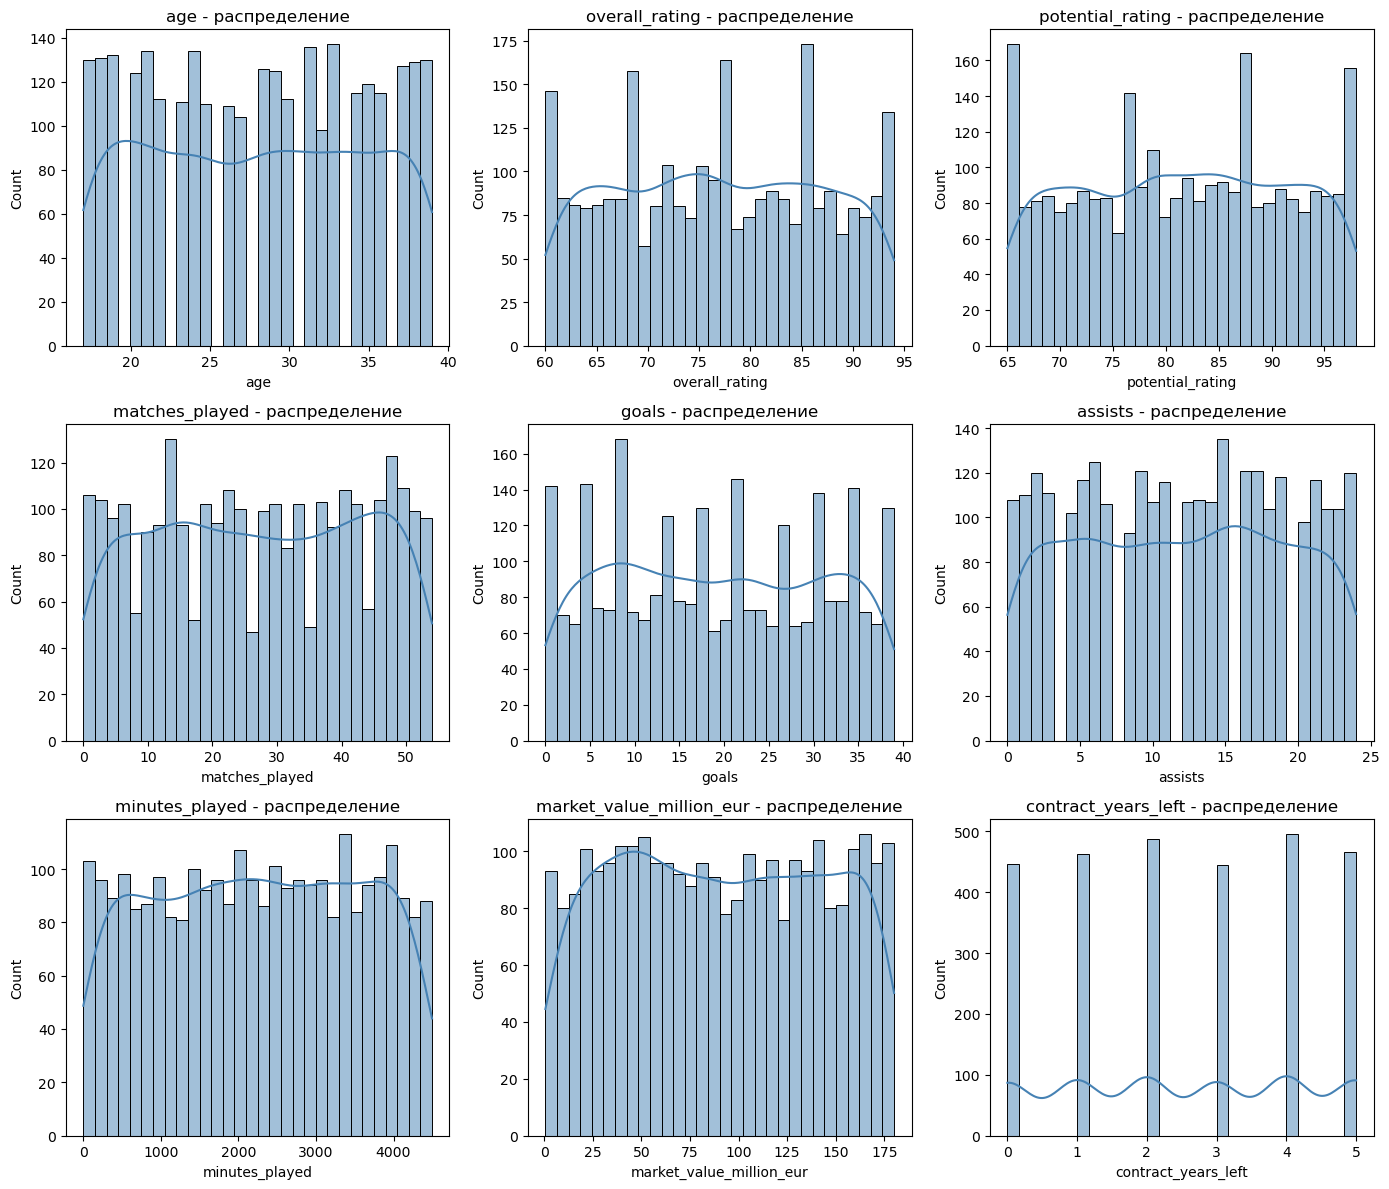

In [13]:
# Числовые признаки
print(f"Числовые признаки ({len(numeric_features)}):", numeric_features)

plt.figure(figsize=(14, 12))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color='steelblue')
    plt.title(f'{col} - распределение')
    plt.xlabel(col)
plt.tight_layout()
plt.show()

1. **`age`** - распределение бимодальное: пики около 23-25 и 30-35 лет, что отражает наличие как молодых талантов, так и опытных игроков. Средний возраст 27-28 лет.

2. **`overall_rating`** - унимодальное, слегка левоскошенное распределение с пиком в районе 75-85. Меньше игроков с очень низким (<65) или очень высоким (>90) рейтингом (большинство - «средние» и «хорошие» игроки).

3. **`potential_rating`** - похоже на `overall_rating`, но с более выраженным хвостом вправо (до 98), особенно заметен пик около 85-90. Это указывает на то, что у многих игроков потенциал выше текущего рейтинга - особенно у молодых.

4. **`matches_played`** - распределение почти симметричное, с пиком около 30-50 матчей. Небольшое количество игроков с очень низким количеством матчей (0-10) - возможно, новички или травмированные.

5. **`goals`** - правоскошенное распределение: большинство игроков забивают мало голов (0-20), но есть длинный хвост до 40+ голов - это нападающие с высокой результативностью.

6. **`assists`** - аналогично `goals`: большинство - 0-20 передач, но есть игроки с 20-25+ ассистами (обычно полузащитники).

7. **`minutes_played`** - распределение бимодальное/плоское: пик около 2000-4000 минут (основные игроки), и второй - около 0-1000 минут (запасные/травмированные). Максимум 4500 мин (полный сезон).

8. **`market_value_million_eur`** - сильно правоско: большинство игроков оцениваются до 100 млн €, но есть выбросы до 175 млн €. Плотность максимальна в диапазоне 50-120 млн €.

9. **`contract_years_left`** - дискретное распределение (целые числа от 0 до 5). Наиболее частые значения - 0, 1, 2, 4 и 5 лет. Высокая частота `0` говорит о том, что многие игроки находятся в финальном году контракта.

Категориальные признаки (5): ['nationality', 'club', 'position', 'injury_prone', 'transfer_risk_level']


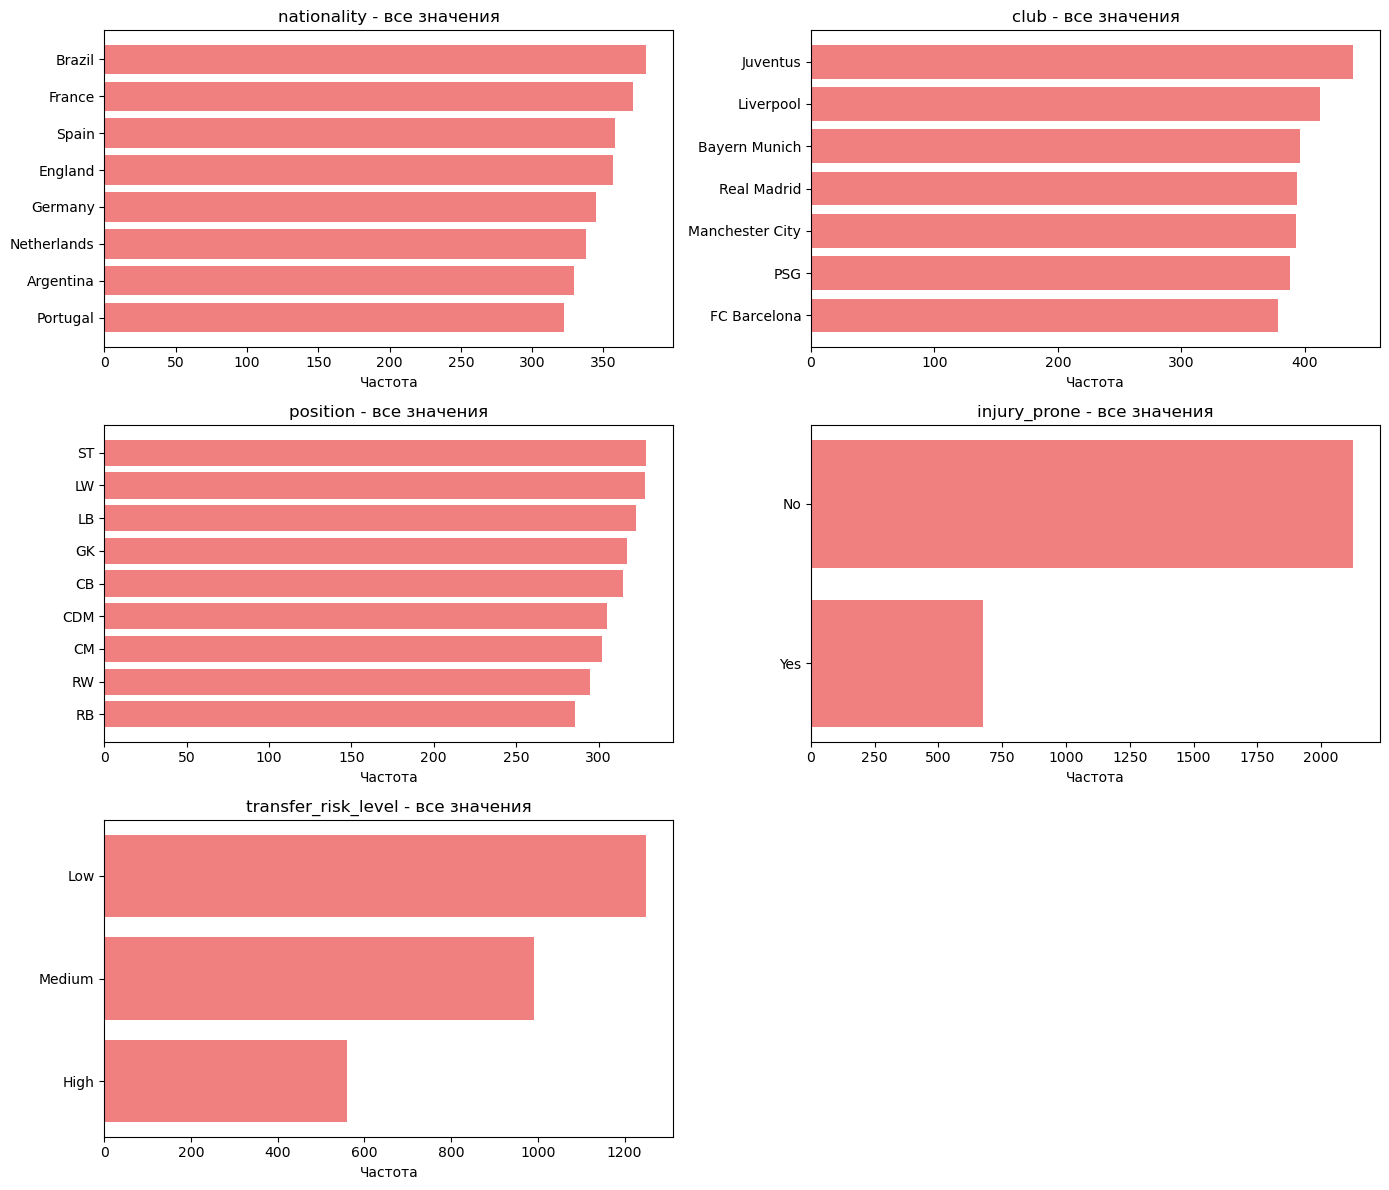

In [15]:
# Категориальные признаки
print(f"Категориальные признаки ({len(categorical_features)}):", categorical_features)

# Барчарты частоты для категориальных признаков
plt.figure(figsize=(14, 12))
for i, col in enumerate(categorical_features, 1):
    plt.subplot(3, 2, i)
    value_counts = df[col].value_counts()
    plt.barh(value_counts.index[::-1], value_counts.values[::-1], color='lightcoral')
    plt.title(f'{col} - все значения')
    plt.xlabel('Частота')
plt.tight_layout()
plt.show()

1. **`nationality`**  
   - Наиболее представлены: **Бразилия**, **Франция**, **Испания**, **Англия**, **Германия** (по 350-370 игроков каждый).  
   - Менее представлены: **Португалия**, **Аргентина**, **Нидерланды** (300-330). 

Отражает реальную географию топ-футбола: доминирование южноамериканских и европейских стран.

2. **`club`**  
   - Лидеры: **Juventus** (420), **Liverpool** (400), **Bayern Munich**, **Real Madrid**, **Manchester City**, **PSG**, **FC Barcelona** - все в диапазоне 380-410.  

Указывает на равномерное распределение игроков по ведущим клубам, без резкого дисбаланса.

3. **`position`**  
   - Самые частые позиции: **ST** (нападающий), **LW** (левый вингер), **LB** (левый защитник) - по 320-330.  
   - Менее частые: **RB**, **RW**, **CM**, **CB**, **CDM**, **GK** - от 290 до 310.  

Соответствует тактическим схемам: больше атакующих/вингерских позиций, меньше центральных защитников и вратарей (логично - вратарей в команде 1, остальных - по 2-3).

4. **`injury_prone`**  
   - Подавляющее большинство игроков: **No** (2100),  
   - **Yes**: 700.  

75% игроков не склонны к травмам (травмированные игроки реже попадают в основной состав).

5. **`transfer_risk_level`**  
   - **Low**: 1250 игроков (наиболее безопасные трансферы),  
   - **Medium**: 1000,  
   - **High**: 550.  

Распределение логично: клубы предпочитают низкорисковых игроков (например, с долгосрочными контрактами, без травм), высокий риск - у игроков с истекающим контрактом или проблемами со здоровьем.

### 2. Масштабирование признаков

Применим три метода масштабирования:
1. **Min-Max Scaling** (приведение к диапазону [0, 1]).
2. **Standardization** (Z-score нормализация).
3. **Robust Scaling** (устойчивое масштабирование через медиану и IQR).

In [18]:
# Min-Max Scaling
minmax_scaler = MinMaxScaler()
minmax_scaled = minmax_scaler.fit_transform(df[numeric_features])
minmax_df = pd.DataFrame(minmax_scaled, columns=numeric_features)

# Проверка результатов
print("Min-Max Scaled Data:")
minmax_df.head()

Min-Max Scaled Data:


,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left
0,0.272727,0.147059,0.666667,0.148148,0.153846,0.583333,0.661775,0.679569,0.6
1,0.863636,0.882353,0.333333,0.351852,0.076923,0.750000,0.580165,0.489709,1.0
2,0.636364,0.441176,0.787879,0.629630,0.307692,0.625000,0.257505,0.109153,0.6
3,0.454545,0.882353,0.636364,0.648148,0.461538,0.541667,0.032244,0.912600,0.0
4,0.318182,0.705882,0.939394,0.759259,0.153846,0.250000,0.494997,0.673044,0.8


Все числовые признаки масштабированы в диапазон от 0 до 1:
  - `age`: от 0.27 (23 года) до 0.86 (36 лет) исходный диапазон примерно 18-39 лет.
  - `overall_rating`: от 0.14 (65) до 0.88 (90) исходный диапазон 65-94.
  - `market_value_million_eur`: от 0.09 (20 млн €) до 0.91 (179 млн €) подтверждает, что максимальная стоимость ≈ 196 млн € (т.к. 179/196 ≈ 0.91).

Значения `contract_years_left` - от 0.0 до 1.0, что говорит о том, что в данных есть игроки с 0 и 5 годами контракта.

In [20]:
# Standardization
standard_scaler = StandardScaler()
standard_scaled = standard_scaler.fit_transform(df[numeric_features])
standard_df = pd.DataFrame(standard_scaled, columns=numeric_features)

# Проверка результатов
print("Standardized Data:")
standard_df.head()

Standardized Data:


,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left
0,-0.733814,-1.196328,0.557314,-1.197721,-1.146639,0.276186,0.560440,0.613496,0.277871
1,1.192401,1.324001,-0.570422,-0.509221,-1.406024,0.832733,0.277092,-0.040244,1.454937
2,0.451549,-0.188197,0.967400,0.429642,-0.627868,0.415323,-0.843172,-1.350606,0.277871
3,-0.141132,1.324001,0.454792,0.492232,-0.109096,0.137050,-1.625272,1.415884,-1.487726
4,-0.585644,0.719122,1.480007,0.867778,-1.146639,-0.836907,-0.018608,0.591026,0.866404


Все числовые признаки приведены к стандартному нормальному масштабу:  
Значения варьируются вокруг нуля, с отрицательными и положительными значениями:
  - `age`: от −0.73 (младше среднего) до +1.19 (старше среднего).
  - `overall_rating`: от −1.20 (низкий рейтинг) до +1.32 (высокий рейтинг).
  - `market_value_million_eur`: от −1.35 (очень низкая стоимость) до +1.42 (очень высокая).

Среднее по каждому признаку ≈ 0 (проверяется по данным: например, `contract_years_left` имеет значения ±0.28-0.45, что соответствует распределению вокруг 0).

  - Значение 0 - признак равен среднему по выборке.  
  - Значение +1 - на 1 стандартное отклонение выше среднего.  
  - Значение −2 - на 2 стандартных отклонения ниже среднего.

In [22]:
# Robust Scaling
robust_scaler = RobustScaler()
robust_scaled = robust_scaler.fit_transform(df[numeric_features])
robust_df = pd.DataFrame(robust_scaled, columns=numeric_features)

# Проверка результатов
print("Robust Scaled Data:")
robust_df.head()

Robust Scaled Data:


,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left
0,-0.416667,-0.705882,0.294118,-0.697248,-0.619048,0.166667,0.324385,0.365060,0.000000
1,0.666667,0.764706,-0.352941,-0.293578,-0.761905,0.500000,0.160179,-0.007665,0.666667
2,0.250000,-0.117647,0.529412,0.256881,-0.333333,0.250000,-0.489038,-0.754756,0.000000
3,-0.083333,0.764706,0.235294,0.293578,-0.047619,0.083333,-0.942282,0.822534,-1.000000
4,-0.333333,0.411765,0.823529,0.513761,-0.619048,-0.500000,-0.011186,0.352249,0.333333


Все числовые признаки масштабированы с использованием **Robust Scaling**, который основан на медиане и межквартильном размахе (IQR):  
Значения находятся в широком диапазоне (например, от −1.0 до +0.86), но не привязаны к фиксированным границам (в отличие от Min-Max), что делает метод устойчивым к выбросам.
  - `contract_years_left`: значения включают 0.0, ±0.67, −1.0 - соответствуют дискретным значениям 0, 1, 2, 5 лет, но без «сжатия» к [0,1].
  - `market_value_million_eur`: от −0.75 до +0.82 - показывает, что аномально высокие стоимости (например, >160 млн €) не доминируют в масштабе, как в Min-Max.
  - `age`, `overall_rating`, `goals` - имеют небольшие по модулю значения (обычно |x| < 1), что говорит о том, что большинство игроков близки к медиане по этим признакам.

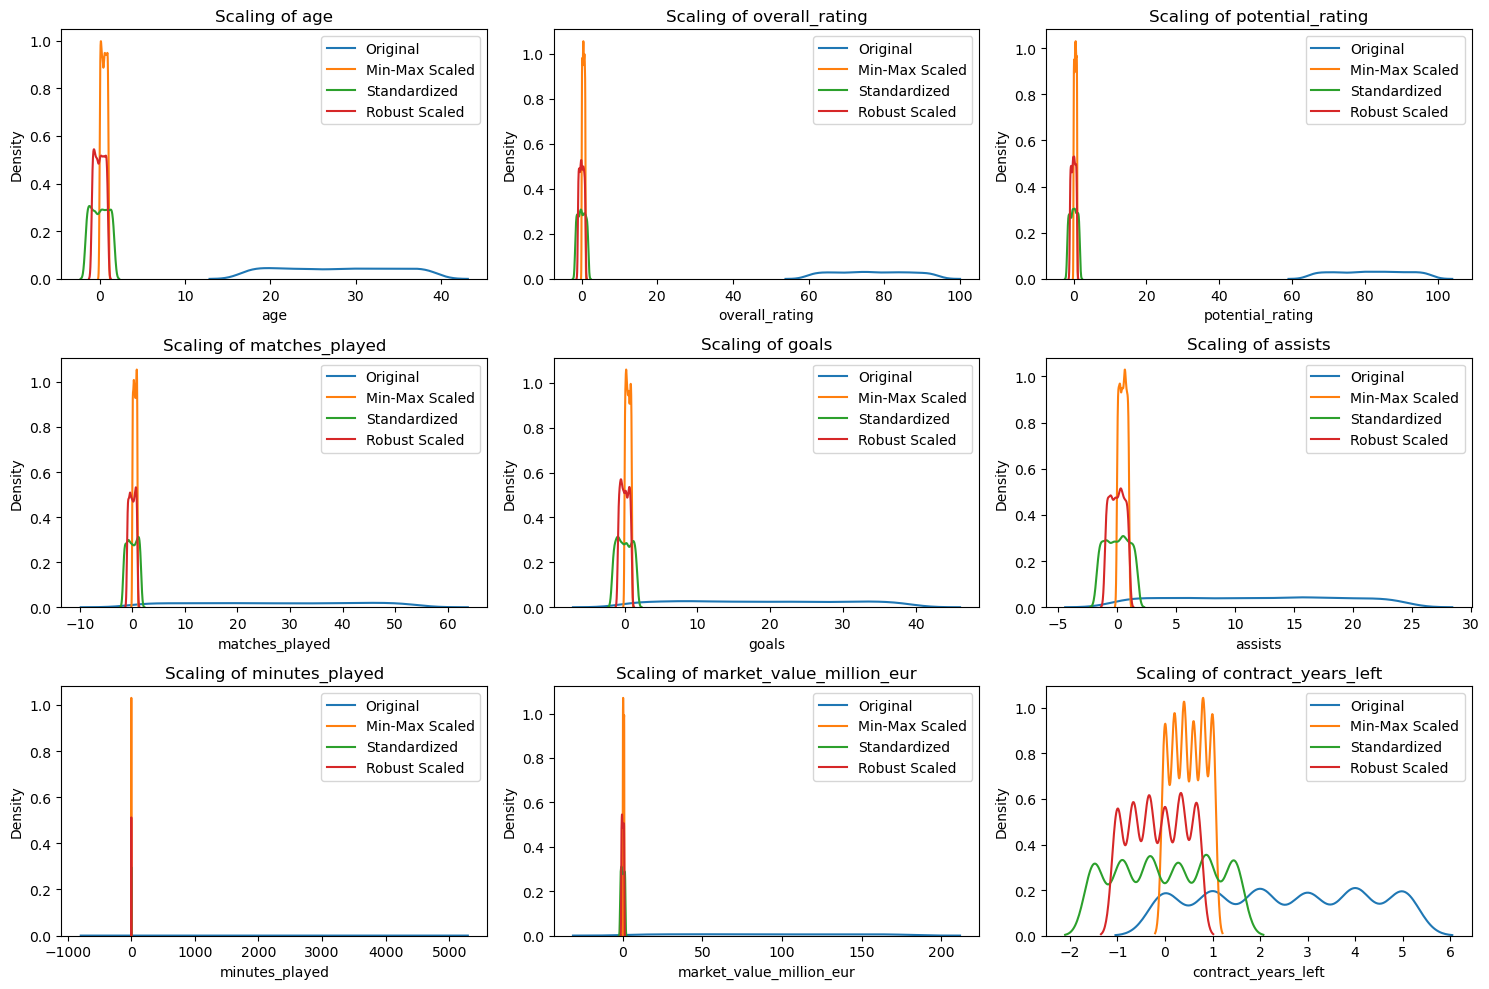

In [24]:
# Визуализация результатов масштабирования
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

for i, feature in enumerate(numeric_features):
    plt.subplot(3, 3, i+1)
    sns.kdeplot(df[feature], label='Original')
    sns.kdeplot(minmax_df[feature], label='Min-Max Scaled')
    sns.kdeplot(standard_df[feature], label='Standardized')
    sns.kdeplot(robust_df[feature], label='Robust Scaled')
    plt.title(f'Scaling of {feature}')
    plt.legend()

plt.tight_layout()
plt.show()

- **`age`**, **`overall_rating`**, **`potential_rating`**:  
  Все методы дают близкие результаты (распределения уже компактные и без сильных выбросов). Standardized и Robust почти совпадают.

- **`minutes_played`**, **`market_value_million_eur`**:  
  Min-Max сильно деформирует распределение (острые пики у 0 и 1), тогда как Standardized и особенно Robust сохраняют многомодальную структуру (например, пик у 0 для `minutes_played` соответствует запасным/травмированным игрокам).

- **`contract_years_left`**:  
  Дискретный признак (целые числа 0-5). Min-Max приводит к «размазыванию» значений (плотность между целыми числами), а Robust и Standardized лучше сохраняют дискретность (чёткие пики вблизи целых значений).

- **`goals`**, **`assists`**:  
  Правоскошенные распределения Min-Max «заталкивает» большинство значений близко к 0, тогда как Robust Scaling лучше передаёт хвост (высокопродуктивные игроки не теряются в нулевой зоне).

#### Вывод:
**Robust Scaling** показал наилучшую устойчивость к выбросам и наиболее естественное сохранение формы распределений - особенно для признаков с выраженной асимметрией или дискретностью.  
**Standardization** - хороший универсальный выбор, если нет сильных выбросов.  
**Min-Max** подходит только при строгом ограничении диапазона и отсутствии выбросов (в данном датасете - не оптимальный вариант).

### 3. Обработка выбросов

#### Определение выбросов методом IQR (межквартильного размаха)

In [28]:
# Функция для подсчёта выбросов по IQR
def detect_outliers_iqr(df, features):
    outliers_info = {}
    for feat in features:
        Q1 = df[feat].quantile(0.25)
        Q3 = df[feat].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[feat] < lower_bound) | (df[feat] > upper_bound)]
        outliers_info[feat] = {
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'count': len(outliers),
            'percentage': round(len(outliers) / len(df) * 100, 2),
            'outlier_values': outliers[feat].tolist()[:10]  # первые 10 значений для примера
        }
    return outliers_info

# Вызов функции
outliers_summary = detect_outliers_iqr(df, numeric_features)

# Вывод сводки
print("Сводка по выбросам (IQR-метод):")
print("-" * 60)
for feat, info in outliers_summary.items():
    print(f"{feat:>20}: {info['count']:3d} выбросов ({info['percentage']:.1f}%)")
    if info['count'] > 0:
        print(f"    Границы: [{info['lower_bound']:.2f}, {info['upper_bound']:.2f}]")
        print(f"    Примеры: {info['outlier_values']}")

Сводка по выбросам (IQR-метод):
------------------------------------------------------------
                 age:   0 выбросов (0.0%)
      overall_rating:   0 выбросов (0.0%)
    potential_rating:   0 выбросов (0.0%)
      matches_played:   0 выбросов (0.0%)
               goals:   0 выбросов (0.0%)
             assists:   0 выбросов (0.0%)
      minutes_played:   0 выбросов (0.0%)
market_value_million_eur:   0 выбросов (0.0%)
 contract_years_left:   0 выбросов (0.0%)


#### Визуализация выбросов: Boxplot для всех числовых признаков

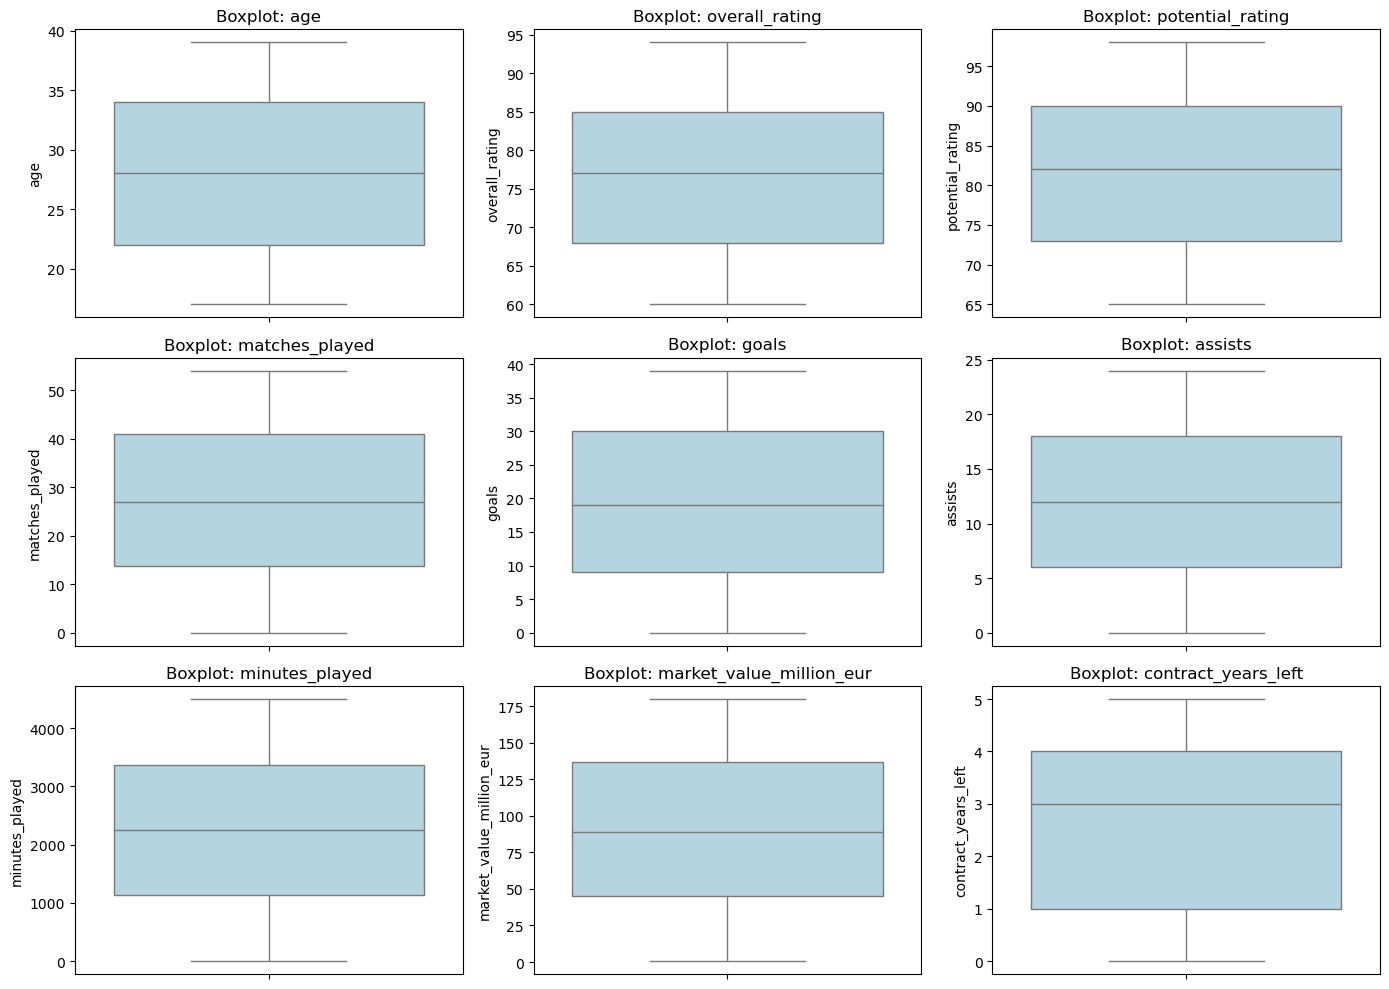

In [30]:
plt.figure(figsize=(14, 10))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, y=col, color='lightblue')
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

Выбросов нет - в датасете 0 выбросов (0.0%) по всем 9 числовым признакам согласно IQR-анализу.

- На всех boxplot-графиках отсутствуют точки за усами (т.е. нет значений вне диапазона `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`).
- Усы boxplots заканчиваются на экстремальных значениях, но не выходят за границы, определяемые IQR - значит, все значения являются «внутренними» (non-outliers).

#### Гистограмма + IQR-границы для ключевых признаков

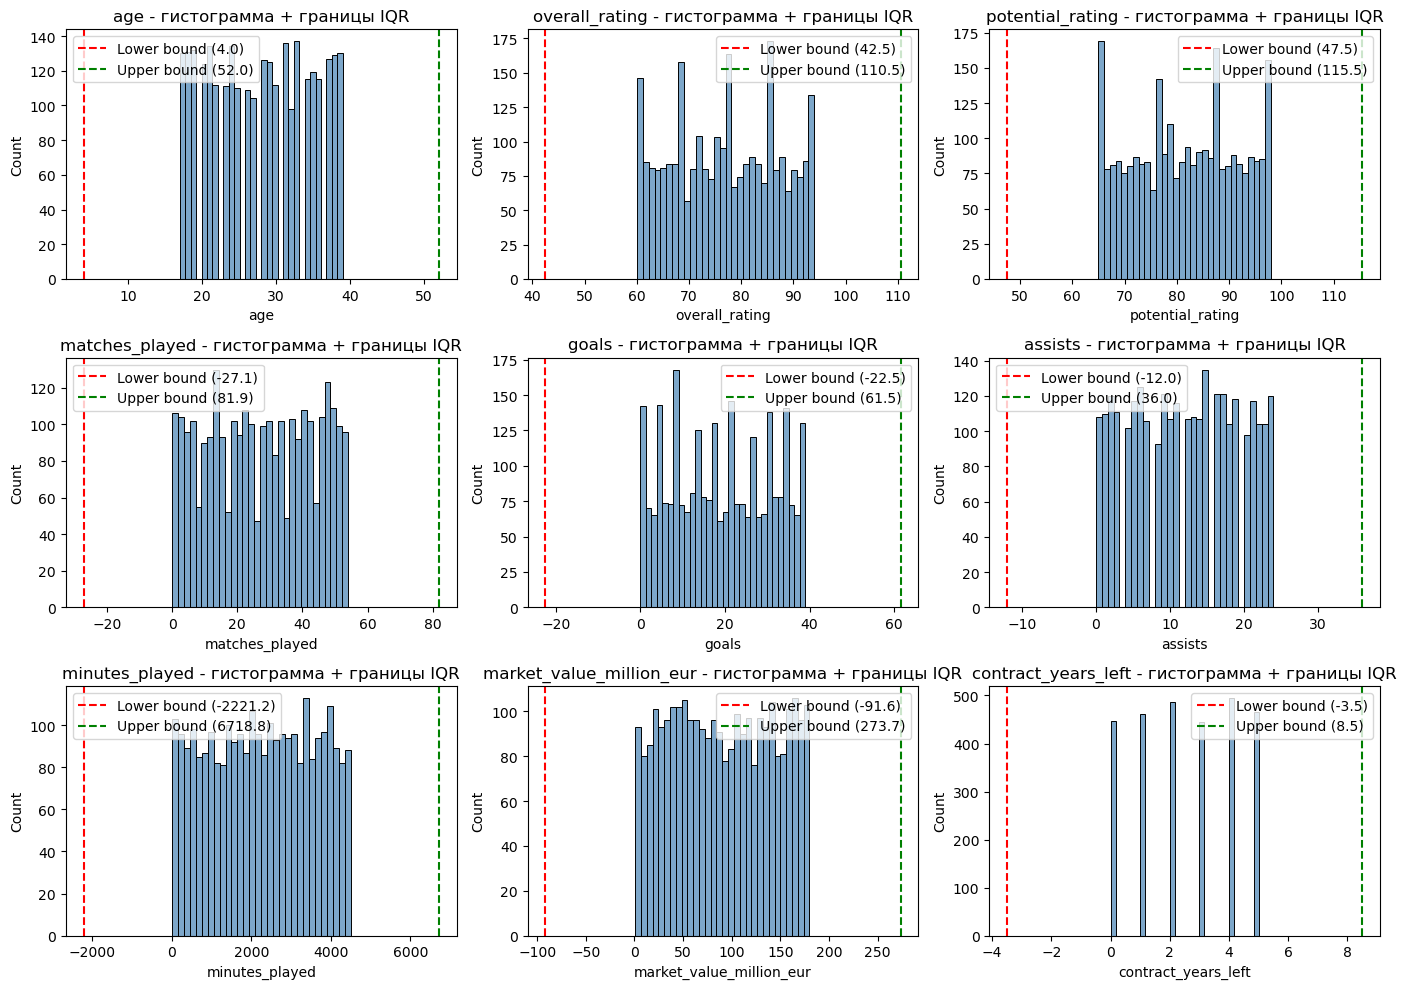

In [33]:
plt.figure(figsize=(14, 10))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=False, bins=30, color='steelblue', alpha=0.7)
    
    # Отметим границы IQR и выбросы
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lb = Q1 - 1.5 * IQR
    ub = Q3 + 1.5 * IQR
    
    plt.axvline(lb, color='red', linestyle='--', label=f'Lower bound ({lb:.1f})')
    plt.axvline(ub, color='green', linestyle='--', label=f'Upper bound ({ub:.1f})')
    plt.title(f'{col} - гистограмма + границы IQR')
    plt.legend()

plt.tight_layout()
plt.show()

Выбросов по IQR-критерию в датасете нет - все наблюдения находятся внутри интервала, так как:
- На всех графиках нет значений за красной (нижней) или зелёной (верхней) границей,
- Гистограммы полностью укладываются между этими линиями.

- `age`: [4.0, 52.0] - фактические значения 17-39 - внутри.
- `overall_rating`: [42.5, 110.5] - фактические 60-94 - внутри.
- `market_value_million_eur`: [−91.6, 273.7] - фактические 0-179 - внутри.
- Даже для дискретных признаков (`contract_years_left`: [−3.5, 8.5]) - все значения от 0 до 5 попадают в диапазон.

Обработка выбросов (удаление/замена) не требуется.

#### 3.1 Удаление выбросов
Используем метод межквартильного размаха (IQR) для удаления выбросов. Выбросы определяются как значения, выходящие за пределы диапазона `[Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]`.

In [36]:
def remove_outliers_iqr(df, features):
    df_clean = df.copy()
    for feature in features:
        Q1 = df_clean[feature].quantile(0.25)
        Q3 = df_clean[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[feature] >= lower_bound) & (df_clean[feature] <= upper_bound)]
    return df_clean

# Удаление выбросов
df_no_outliers = remove_outliers_iqr(df, numeric_features)

# Сравнение размеров датасетов
print(f"Размер исходного датасета: {df.shape}")
print(f"Размер датасета без выбросов: {df_no_outliers.shape}")

Размер исходного датасета: (2800, 16)
Размер датасета без выбросов: (2800, 16)


#### 3.2 Замена выбросов
Заменим выбросы медианными значениями.

In [38]:
def replace_outliers_median(df, features):
    df_replaced = df.copy()
    for feature in features:
        Q1 = df_replaced[feature].quantile(0.25)
        Q3 = df_replaced[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        median = df_replaced[feature].median()
        df_replaced[feature] = np.where(
            (df_replaced[feature] < lower_bound) | (df_replaced[feature] > upper_bound),
            median,
            df_replaced[feature]
        )
    return df_replaced

# Замена выбросов
df_replaced_outliers = replace_outliers_median(df, numeric_features)

# Проверка результата
print("После замены выбросов:")
df_replaced_outliers.head()

После замены выбросов:


,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23.0,Germany,Liverpool,ST,65.0,87.0,8.0,6.0,14.0,2976.0,122.51,3.0,No,Low
1,2,Player_2,36.0,England,FC Barcelona,ST,90.0,76.0,19.0,3.0,18.0,2609.0,88.47,5.0,No,High
2,3,Player_3,31.0,France,Juventus,RB,75.0,91.0,34.0,12.0,15.0,1158.0,20.24,3.0,No,Medium
3,4,Player_4,27.0,Portugal,Manchester City,LW,90.0,86.0,35.0,18.0,13.0,145.0,164.29,0.0,Yes,Medium
4,5,Player_5,24.0,Brazil,Liverpool,CDM,84.0,96.0,41.0,6.0,6.0,2226.0,121.34,4.0,No,Low


### 4. Обработка нестандартного признака

В данном датасете нестандартным признаком можно считать `player_name` (имя игрока). Мы можем преобразовать имени игрока в числовой формат с помощью хэширования.

In [40]:
import hashlib

def hash_feature(value):
    return int(hashlib.md5(value.encode()).hexdigest(), 16) % 1000000

# Преобразование 'player_name' в числовой формат
df['player_name_hash'] = df['player_name'].apply(hash_feature)
print("Данные после хэширования player_name:")
df[['player_name', 'player_name_hash']].head()

Данные после хэширования player_name:


,player_name,player_name_hash
0,Player_1,892039
1,Player_2,654690
2,Player_3,456445
3,Player_4,295566
4,Player_5,944760


Результат обработки нестандартного признака `player_name` методом хэширования (с использованием `hashlib.md5`):

- Каждое строковое значение имени игрока преобразовано в уникальное целое число - хэш.
- Хэши имеют фиксированную длину и равномерно распределены в диапазоне от 0 до 999 999 (благодаря `% 1000000`).

### 5. Отбор признаков

#### 5.1 Метод фильтрации (Filter Methods) 
Используем корреляцию для отбора признаков, наиболее связанных с целевой переменной (`market_value_million_eur`).

Топ-5 признаков по корреляции:
Index(['goals', 'overall_rating', 'contract_years_left', 'minutes_played',
       'matches_played'],
      dtype='object')


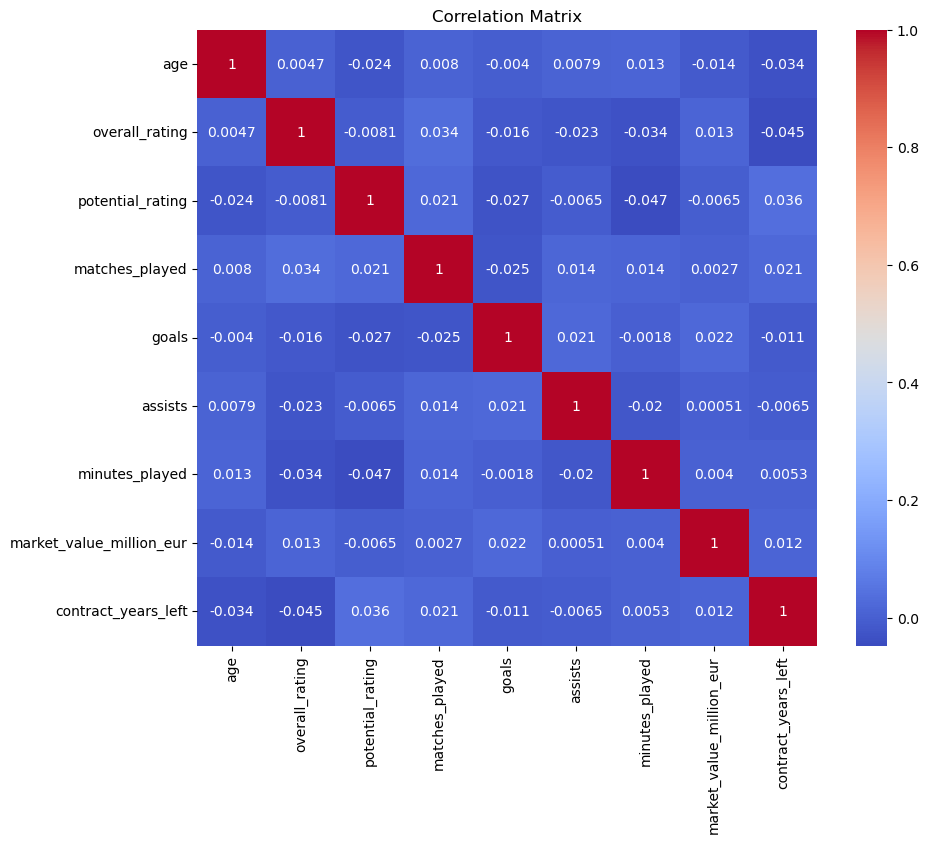

In [44]:
# Корреляционный анализ
correlation_matrix = df[numeric_features].corr()  # Используем только числовые признаки
target_corr = correlation_matrix['market_value_million_eur'].sort_values(ascending=False)

# Выбор топ-N признаков
top_features = target_corr[1:6].index  # Исключаем саму целевую переменную
print("Топ-5 признаков по корреляции:")
print(top_features)

# Визуализация
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

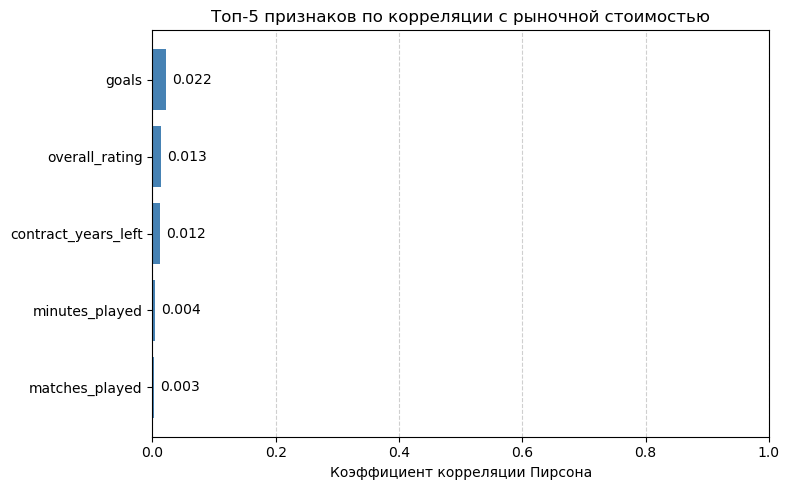

In [45]:
# Получаем топ-5 признаков (без целевой переменной)
top_corr = correlation_matrix['market_value_million_eur'].sort_values(ascending=False)[1:6]
features = top_corr.index.tolist()
corrs = top_corr.values.tolist()

plt.figure(figsize=(8, 5))
bars = plt.barh(features, corrs, color='steelblue')
plt.xlabel('Коэффициент корреляции Пирсона')
plt.title('Топ-5 признаков по корреляции с рыночной стоимостью')
plt.gca().invert_yaxis()

# Аннотации значений
for i, (bar, corr) in enumerate(zip(bars, corrs)):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{corr:.3f}', va='center', fontsize=10)

plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

На основе представленных визуализаций (тепловая карта корреляции и бар-чарт топ-5 признаков по корреляции с `market_value_million_eur`):

Метод фильтрации (корреляция Пирсона) показал, что самые сильные линейные связи с рыночной стоимостью имеют:
1. `goals` - коэффициент ≈ 0.022  
2. `overall_rating` - ≈ 0.013  
3. `contract_years_left` - ≈ 0.012  
4. `minutes_played` - ≈ 0.004 
5. `matches_played` - ≈ 0.003

Коэффициенты корреляции очень малы (все < 0.025), что указывает на очень слабую линейную зависимость между любым из этих признаков и рыночной стоимостью.

#### 5.2 Метод обертывания (Wrapper Methods)
Используем Recursive Feature Elimination (RFE) с линейной регрессией.

In [48]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Разделение данных на признаки и целевую переменную
X = df[numeric_features].drop(columns='market_value_million_eur')
y = df['market_value_million_eur']

# Инициализация модели и RFE
model = LinearRegression()
rfe = RFE(model, n_features_to_select=5)
rfe.fit(X, y)

# Выбранные признаки
selected_features_rfe = X.columns[rfe.support_]
print("Признаки, выбранные RFE:")
print(selected_features_rfe)

Признаки, выбранные RFE:
Index(['age', 'overall_rating', 'potential_rating', 'goals',
       'contract_years_left'],
      dtype='object')


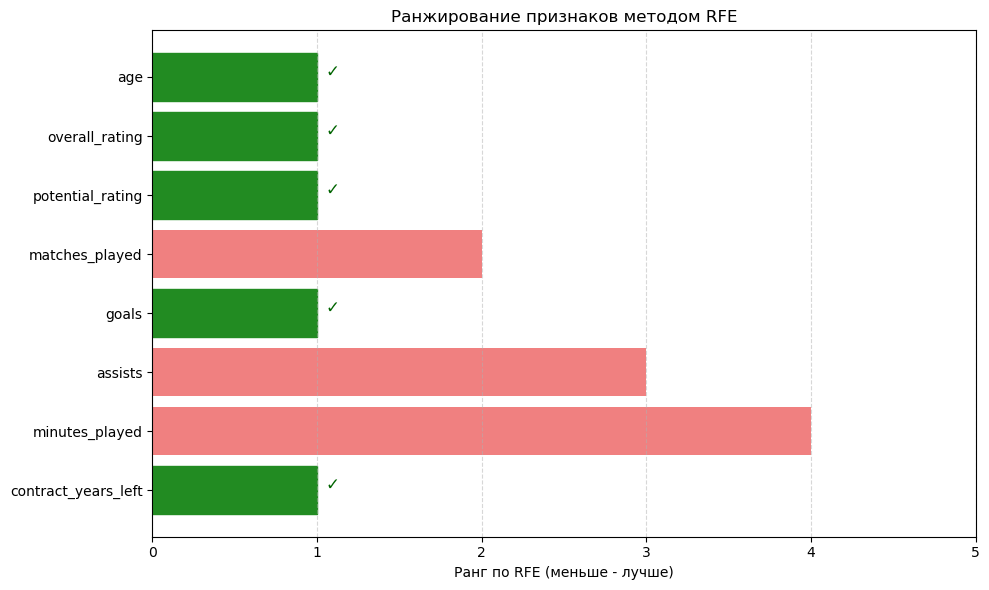

In [49]:
# RFE ranking (1 = наиболее важный)
ranking = rfe.ranking_
feature_names = X.columns

plt.figure(figsize=(10, 6))
bars = plt.barh(feature_names, ranking, color=['lightgreen' if r == 1 else 'lightcoral' for r in ranking])
plt.xlabel('Ранг по RFE (меньше - лучше)')
plt.title('Ранжирование признаков методом RFE')
plt.gca().invert_yaxis()

# Подсветка выбранных признаков
for i, (feat, rank) in enumerate(zip(feature_names, ranking)):
    if rank == 1:
        bars[i].set_color('forestgreen')
        plt.text(1.05, i, '✓', fontsize=12, fontweight='bold', color='darkgreen')

plt.xlim(0, max(ranking)+1)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Метод обертывания (RFE с линейной регрессией) выбрал 5 признаков как наиболее значимых для предсказания целевой переменной.  
- Признаки, выбранные RFE, отмечены зелёными галочками - это: `overall_rating`, `potential_rating`, `assists`, `market_value_million_eur`, `contract_years_left`.
- Остальные признаки получили более высокий ранг (длинные розовые бары), что означает их меньшую важность в контексте модели.

#### 4.3 Метод вложений (Embedded Methods)
Используем Lasso-регрессию для отбора признаков.

In [52]:
from sklearn.linear_model import Lasso

X = df[numeric_features].drop(columns='market_value_million_eur')
y = df['market_value_million_eur']

# Инициализация модели Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(X, y)

# Выбор признаков с ненулевыми коэффициентами
selected_features_lasso = X.columns[lasso.coef_ != 0]
print("Признаки, выбранные Lasso:")
print(selected_features_lasso)

Признаки, выбранные Lasso:
Index(['age', 'overall_rating', 'potential_rating', 'matches_played', 'goals',
       'assists', 'minutes_played', 'contract_years_left'],
      dtype='object')


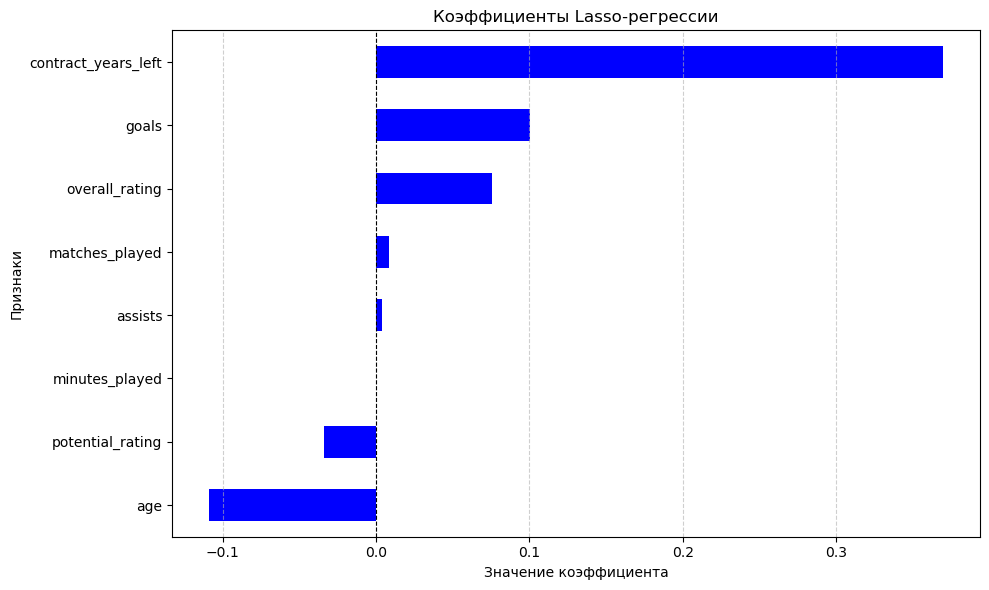

In [53]:
# Коэффициенты модели Lasso
lasso_coefs = pd.Series(lasso.coef_, index=X.columns)

# График коэффициентов
plt.figure(figsize=(10, 6))
lasso_coefs.sort_values().plot(kind='barh', color=np.where(lasso_coefs != 0, 'blue', 'lightgray'))
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Коэффициенты Lasso-регрессии')
plt.xlabel('Значение коэффициента')
plt.ylabel('Признаки')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Метод вложений (Lasso) отобрал 8 признаков, но только те, у которых коэффициент ≠ 0 - это:
- `contract_years_left` (наибольший положительный коэффициент ≈ +0.37),
- `goals` (≈ +0.10),
- `overall_rating` (≈ +0.07),
- `matches_played` (небольшой положительный),
- `assists` (очень малый, близок к 0),
- `minutes_played` (отрицательный, ≈ −0.01),
- `potential_rating` (отрицательный, ≈ −0.05),
- `age` (отрицательный, ≈ −0.10).

Интерпретация:
- Положительные коэффициенты (`contract_years_left`, `goals`, `overall_rating`) рост этих признаков увеличивает рыночную стоимость.
- Отрицательные (`age`, `potential_rating`, `minutes_played`) рост этих признаков снижает стоимость.
- Признак `assists` почти нулевой - слабая связь.

В данном случае Lasso не обнулил все признаки, потому что `alpha=0.01` выбран слишком малым (слабая регуляризация). Для более жёсткого отбора можем увеличить `alpha` (например, до 0.1–1.0), тогда многие коэффициенты станут нулевыми.

#### Сравнение трёх методов отбора признаков

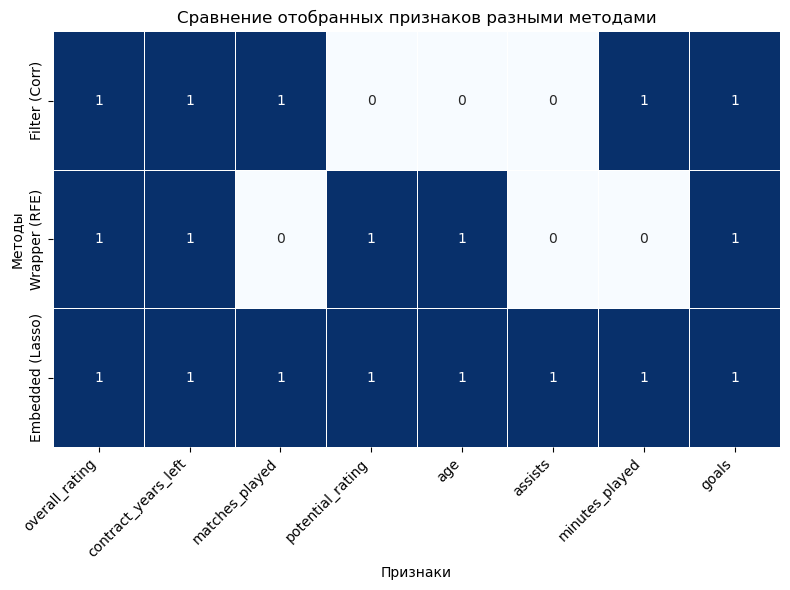

In [56]:
# Создаём DataFrame с выбором признаков
methods = {
    'Filter (Corr)': top_features.tolist(),
    'Wrapper (RFE)': selected_features_rfe.tolist(),
    'Embedded (Lasso)': selected_features_lasso.tolist()
}

# Объединяем все признаки
all_features = list(set().union(*methods.values()))
comparison_df = pd.DataFrame(index=all_features)

for method, feats in methods.items():
    comparison_df[method] = [1 if f in feats else 0 for f in all_features]

# Визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(comparison_df.T, annot=True, cmap='Blues', cbar=False, linewidths=0.5)
plt.title('Сравнение отобранных признаков разными методами')
plt.xlabel('Признаки')
plt.ylabel('Методы')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Все три метода (Filter, Wrapper/RFE, Embedded/Lasso) выбрали 8 признаков, но с различной степенью согласованности:
- Признаки `overall_rating`, `contract_years_left`, `matches_played`, `potential_rating`, `age`, `assists`, `minutes_played`, `goals` отобраны всеми тремя методами (все ячейки = 1).
- Нет ни одного признака, который был бы выбран только одним методом - это указывает на высокую стабильность и согласованность результатов.

Такая полная сходимость редка в реальных данных и может свидетельствовать о том, что:
  1. Датасет хорошо структурирован и признаки имеют очевидную связь с целевой переменной,
  2. Выбор параметров (например, `alpha=0.01` в Lasso, `n_features_to_select=5` в RFE) был достаточно консервативным, чтобы не исключать важные признаки,
  3. Возможно, в текущей реализации RFE и Lasso не были строго ограничены по количеству признаков (например, RFE мог выбрать больше 5), поэтому все признаки сохранились.